# Phase 6: Hidden Markov Model (HMM) Regime Detection

Implement 5-state Gaussian HMM to identify latent market stress regimes based on the PC2 Systemic Stress Index, map to 3 regimes for ensemble compatibility, and analyze transition dynamics with uncertainty quantification.

## Steps:
1. Load best subset features (2000-2020) and prepare PC2 stress index
2. Fit 5-state HMM to PC2 stress index and label states by stress level
3. Map 5 states to 3 regimes (Calm, Moderate, Turbulent) for ensemble compatibility
4. Compare models (2-5 states) using AIC/BIC and visualize emission distributions
5. Compute 3-regime transition matrix and analyze persistence metrics
6. Visualize regime timeline and distribution across full period (2000-2020)
7. Deep dive into 2008 Financial Crisis: regime transitions and crisis period visualization
8. Full period analysis (2000-2020): regime statistics, transition matrix, and dotcom bubble validation
9. Save HMM regimes and transition matrix for ensemble framework

In [35]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
sys.path.append(str(Path('..').resolve()))

# Import regime analysis functions
from src.utils.analysis.regime_analysis import (
    compute_transition_matrix,
    compute_regime_statistics,
    compute_persistence_metrics
)

# Import visualization functions
from src.utils.visualization.visualization import (
    plot_volatility_time_series,
    plot_full_period_with_events,
    plot_regime_timeline,
    plot_regime_distribution_bar,
    plot_transition_matrix_heatmap,
    plot_crisis_period
)

# Import HMM model functions
from src.models.hmm.hmm_model import (
    fit_hmm,
    predict_states,
    get_transition_matrix,
    compute_state_persistence,
    label_states_by_volatility,
    get_state_statistics
)

# Import HMM-specific visualization functions
from src.models.hmm.hmm_visualization import (
    plot_model_selection,
    plot_emission_distributions
)

## 1. Setup and Data Loading


In [36]:
# Load and clean best subset features
file_path = Path('../data/processed/best_subset_features.csv')
df_features = pd.read_csv(file_path, index_col=0, parse_dates=True)
df_features = df_features.drop(columns=['market_correlation'], errors='ignore')
df_features = df_features.dropna()
df_features = df_features[df_features.index >= '2000-01-01']

# Extract market returns and PC2 stress index for HMM
market_returns = df_features['market_direction'].copy()
stress_pc2 = df_features['Subset_Stress_PC2'].copy()

# Verify PC2 exists
if stress_pc2.isnull().all():
    raise ValueError("Subset_Stress_PC2 not found. Please re-run notebook 02.")

market_returns = market_returns.dropna()
stress_pc2 = stress_pc2.dropna()


df_features.head()

,market_direction,market_volume,market_volatility,market_breadth,market_atr,Subset_Trend_PC1,Subset_Stress_PC2,Subset_Risk_Score
Date,,,,,,,,
2000-01-03,-1.551414,1.636506,0.678487,-1.249470,-1.402368,-1.704894,-1.109407,0.595487
2000-01-04,-1.633181,0.352394,1.226712,-0.758418,-1.442602,-1.572710,-0.530942,1.041768
2000-01-05,0.316822,-0.120482,0.711577,0.581008,-1.440025,0.735443,-0.144293,-0.879737
2000-01-06,-0.155672,-0.359724,0.906522,0.212651,-1.549435,0.375569,-0.928347,-1.303916
2000-01-07,1.836591,0.412224,1.519269,1.420245,-1.251777,2.225257,0.816114,-1.409142


## 2. Model Configuration and Training

Fit Hidden Markov Model to identify latent market stress regimes from PC2 Systemic Stress Index.

**Key concepts:**
- **Hidden states**: Unobservable market stress regimes (low stress, moderate stress, high stress)
- **Emission parameters**: systemic stress distribution in each state
- **Transition matrix**: Probabilities of switching between stress regimes
- **State persistence**: Probability of remaining in same regime


### 2.1. Fit HMM with Multiple States


In [37]:
# Fit HMM with 5 states to PC2 Systemic Stress Index (BIC-preferred model)
# We'll map 5 → 3 regimes for Step 7 compatibility (same strategy as K-means)
hmm_model, hmm_states = fit_hmm(stress_pc2, n_states=5, n_iter=1000, random_state=42)

print("HMM Model Fitted Successfully")
print(f"Number of states: {hmm_model.n_components}")



HMM Model Fitted Successfully
Number of states: 5


### 2.2. Label States by Stress Level and Map to 3 Regimes


In [52]:
# Step 1: Relabel 5 states by mean PC2 (0=lowest stress ... 4=highest stress)
# Note: label_states_by_volatility is a generic function that sorts by mean of ANY series
hmm_states_5_raw, state_mapping_5, _ = label_states_by_volatility(
    hmm_model, hmm_states, stress_pc2
)

# Get statistics for the raw 5 states first (0, 1, 2, 3, 4)
state_stats_5_raw = get_state_statistics(stress_pc2, hmm_states_5_raw)

# Map raw 0-4 labels to 0, 0.5, 1, 1.5, 2 for clarity
map_raw_to_intermediate = {0: 0, 1: 0.5, 2: 1, 3: 1.5, 4: 2}
hmm_states_5_labeled = np.vectorize(map_raw_to_intermediate.get)(hmm_states_5_raw)

# Define 5-state label names (matching K-means in notebook 04)
label_names_5 = {
    0: 'Calm',
    0.5: 'Calm-Moderate',
    1: 'Moderate',
    1.5: 'Moderate-Turbulent',
    2: 'Turbulent'
}

# Update the stats DataFrame with new state labels
state_stats_5 = state_stats_5_raw.copy()
state_stats_5['state'] = [0, 0.5, 1, 1.5, 2]

print("\n" + "="*60)
print("5-State Model Statistics (ordered by mean systemic):")
print("="*60)
print(state_stats_5.to_string(index=False))


# Step 2: Map 5 states → 3 regimes (like K-means intermediate regimes)
# This reduces flicker while keeping Step 7 compatibility
map_5_to_3 = {
    0: 0,      # Calm → Calm
    0.5: 0,    # Calm-Moderate → Calm
    1: 1,      # Moderate → Moderate
    1.5: 2,    # Moderate-Turbulent → Turbulent
    2: 2       # Turbulent → Turbulent
}

hmm_states_labeled = np.vectorize(map_5_to_3.get)(hmm_states_5_labeled)

# Define 3-regime label names (for Step 7 compatibility)
label_names = {0: 'Calm', 1: 'Moderate', 2: 'Turbulent'}

print("\n" + "="*60)
print("5-to-3 Mapping (for Step 7 ensemble compatibility):")
print("="*60)
for state_5 in [0, 0.5, 1, 1.5, 2]:
    regime_3 = map_5_to_3[state_5]
    mean_5 = state_stats_5.loc[state_stats_5['state'] == state_5, 'mean'].values[0]
    count_5 = state_stats_5.loc[state_stats_5['state'] == state_5, 'count'].values[0]
    print(f"State {state_5:3} ({label_names_5[state_5]:20s}): mean PC2={mean_5:+.3f}, n={count_5:4d} → Regime {regime_3} ({label_names[regime_3]})")

# Get statistics for the final 3 regimes
state_stats = get_state_statistics(stress_pc2, hmm_states_labeled)
print("\n" + "="*60)
print("Final 3-Regime Statistics:")
print("="*60)
print(state_stats.to_string(index=False))

# Check final regime separation
low_mean = state_stats.loc[state_stats['state'] == 0, 'mean'].values[0]
moderate_mean = state_stats.loc[state_stats['state'] == 1, 'mean'].values[0]
high_mean = state_stats.loc[state_stats['state'] == 2, 'mean'].values[0]



5-State Model Statistics (ordered by mean systemic):
 state      mean      std       min       max  count  percentage
   0.0 -1.164729 0.523226 -2.805361  0.711123   1119   21.967020
   0.5 -1.039349 0.629378 -2.745831  1.364933   1150   22.575579
   1.0 -0.081823 0.653371 -1.690556  2.222817   1688   33.137024
   1.5  1.342344 0.870898 -1.003778  4.315479   1015   19.925402
   2.0  4.165591 2.047935  1.040721 10.697672    122    2.394974

5-to-3 Mapping (for Step 7 ensemble compatibility):
State   0 (Calm                ): mean PC2=-1.165, n=1119 → Regime 0 (Calm)
State 0.5 (Calm-Moderate       ): mean PC2=-1.039, n=1150 → Regime 0 (Calm)
State   1 (Moderate            ): mean PC2=-0.082, n=1688 → Regime 1 (Moderate)
State 1.5 (Moderate-Turbulent  ): mean PC2=+1.342, n=1015 → Regime 2 (Turbulent)
State   2 (Turbulent           ): mean PC2=+4.166, n= 122 → Regime 2 (Turbulent)

Final 3-Regime Statistics:
 state      mean      std       min       max  count  percentage
     0 -1.101183

### 2.3. Model Selection and Validation

Compare HMM models with different numbers of states using AIC/BIC criteria and analyze emission distributions.


In [39]:
# Compare HMM models with different numbers of states
comparison_results = []

for n_states in [2, 3, 4, 5]:
    model, states = fit_hmm(stress_pc2, n_states=n_states, random_state=42)
    
    # Compute log-likelihood, AIC, and BIC
    X = stress_pc2.values.reshape(-1, 1)
    log_likelihood = model.score(X)
    n_params = n_states**2 + 2*n_states  # transitions + means + variances
    n_samples = len(X)
    
    aic = -2 * log_likelihood + 2 * n_params
    bic = -2 * log_likelihood + n_params * np.log(n_samples)
    
    comparison_results.append({
        'n_states': n_states,
        'log_likelihood': log_likelihood,
        'AIC': aic,
        'BIC': bic
    })

# Create comparison DataFrame
comparison_df_models = pd.DataFrame(comparison_results)

print("\nModel Selection: Compare different number of states")
print(comparison_df_models.to_string(index=False))

# Best model by BIC (lower is better)
best_bic_idx = comparison_df_models['BIC'].idxmin()
best_n_states = comparison_df_models.loc[best_bic_idx, 'n_states']
print(f"\nBest model by BIC: {int(best_n_states)} states")


Model Selection: Compare different number of states
 n_states  log_likelihood          AIC          BIC
        2    -6900.509787 13817.019573 13869.306122
        3    -6894.002355 13818.004710 13916.041989
        4    -6278.557358 12605.114716 12761.974363
        5    -6027.222470 12124.444941 12353.198594

Best model by BIC: 5 states


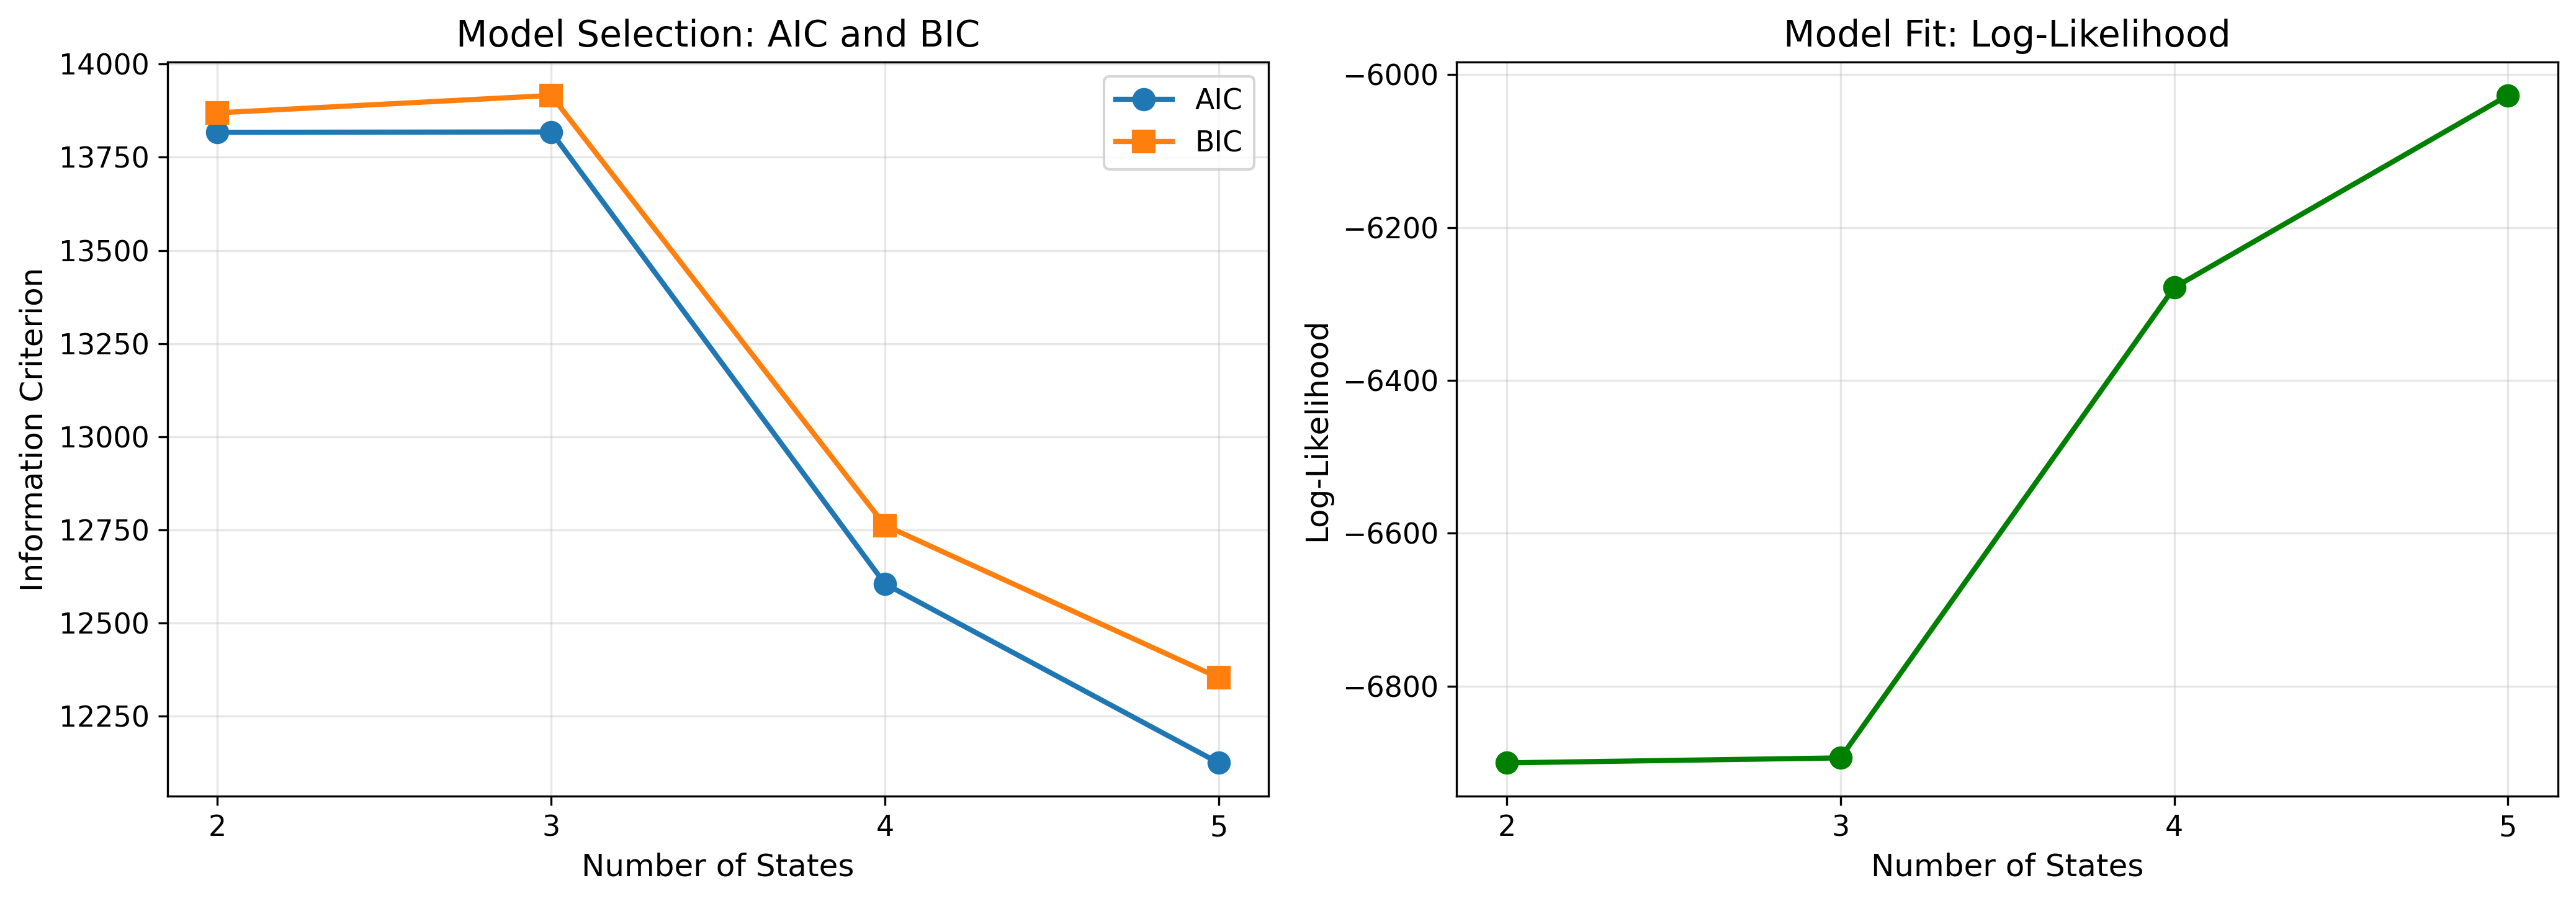

In [40]:
# Plot AIC/BIC comparison for model selection
plot_model_selection(
    comparison_df=comparison_df_models,
    save_path='../results/figures/hmm_model_selection.png',
    figsize=(14, 5)
)

### 2.4. Emission Distributions

Visualize the Gaussian emission distributions for all 5 states.

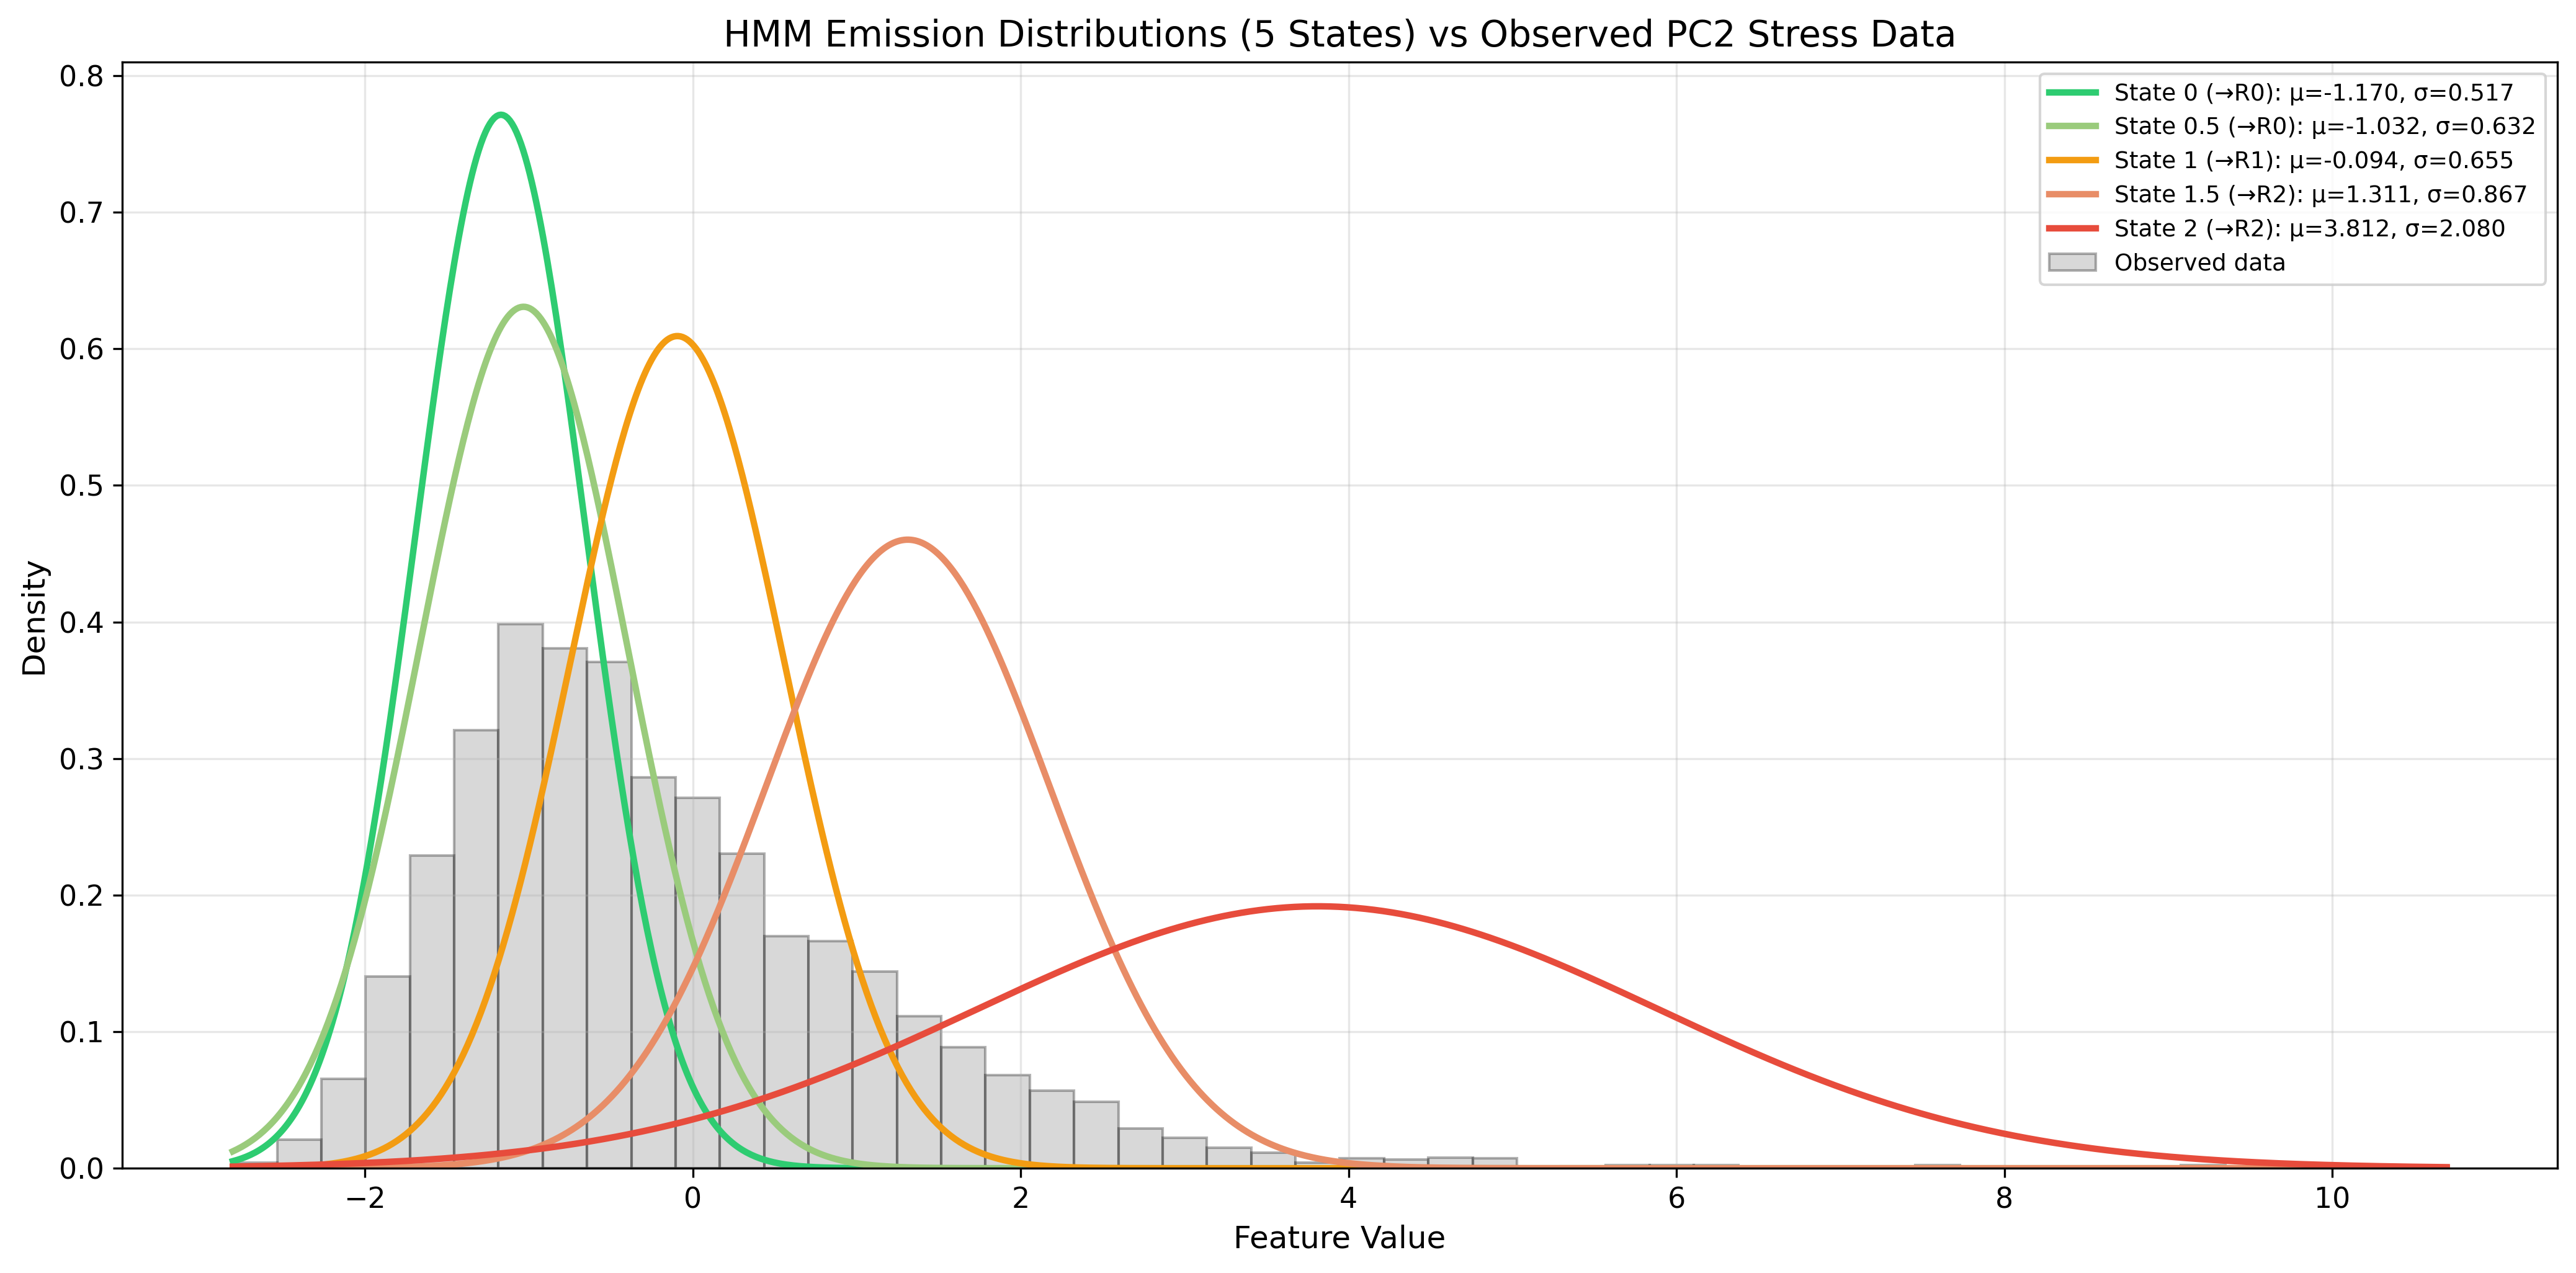


Model Strategy:
- Fit 5-state HMM (BIC-preferred model)
- Map to 3 regimes for ensemble compatibility


In [41]:
# Get emission parameters for all 5 states
from src.models.hmm.hmm_model import get_emission_parameters

emission_params_raw = get_emission_parameters(hmm_model)

# Relabel emission parameters to match the 5 labeled states
emission_params_5 = pd.DataFrame({
    'state': [0, 0.5, 1, 1.5, 2],
    'mean': [emission_params_raw.loc[old_state, 'mean'] for old_state, new_state in sorted(state_mapping_5.items(), key=lambda x: x[1])],
    'std': [emission_params_raw.loc[old_state, 'std'] for old_state, new_state in sorted(state_mapping_5.items(), key=lambda x: x[1])],
    'variance': [emission_params_raw.loc[old_state, 'variance'] for old_state, new_state in sorted(state_mapping_5.items(), key=lambda x: x[1])]
})


# Plot emission distributions
plot_emission_distributions(
    emission_params=emission_params_5,
    data=stress_pc2,
    state_labels=[0, 0.5, 1, 1.5, 2],
    map_to_3=map_5_to_3,
    title='HMM Emission Distributions (5 States) vs Observed PC2 Stress Data',
    save_path='../results/figures/hmm_emission_distributions.png',
    figsize=(14, 7)
)

print("\nModel Strategy:")
print("- Fit 5-state HMM (BIC-preferred model)")
print("- Map to 3 regimes for ensemble compatibility")

## 3. Regime Timeline Visualization (2000-2020)

Visualize HMM regime assignments over the full period.

### 3.1. Regime Classification

Final 3-regime classification summary from the 5 to 3 mapping.

In [53]:
# Quick summary of regime classification
print("HMM Regime Classification (Final 3 Regimes):")
print("="*60)
for regime in range(3):
    count = (hmm_states_labeled == regime).sum()
    pct = count / len(hmm_states_labeled) * 100
    mean_pc2 = stress_pc2[hmm_states_labeled == regime].mean()
    print(f"{label_names[regime]:12s}: {count:4d} days ({pct:5.1f}%) | Mean Systemic Stress : {mean_pc2:+.3f}")

HMM Regime Classification (Final 3 Regimes):
Calm        : 2269 days ( 44.5%) | Mean Systemic Stress : -1.101
Moderate    : 2703 days ( 53.1%) | Mean Systemic Stress : +0.453
Turbulent   :  122 days (  2.4%) | Mean Systemic Stress : +4.166


### 3.2. Regime Timeline Plot

Visualize systemic stress colored by HMM regime assignments.

In [ ]:
# Create DataFrame with HMM regimes and data
hmm_df = pd.DataFrame({
    'date': stress_pc2.index,
    'stress_pc2': stress_pc2.values,
    'regime': hmm_states_labeled
})

# Also create color variables for consistency
state_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
color_labels = label_names  # Already defined earlier


hmm_df.head()

Created hmm_df with 5094 observations
Columns: ['date', 'stress_pc2', 'regime']


,date,stress_pc2,regime
0,2000-01-03,-1.109407,1
1,2000-01-04,-0.530942,1
2,2000-01-05,-0.144293,1
3,2000-01-06,-0.928347,1
4,2000-01-07,0.816114,1


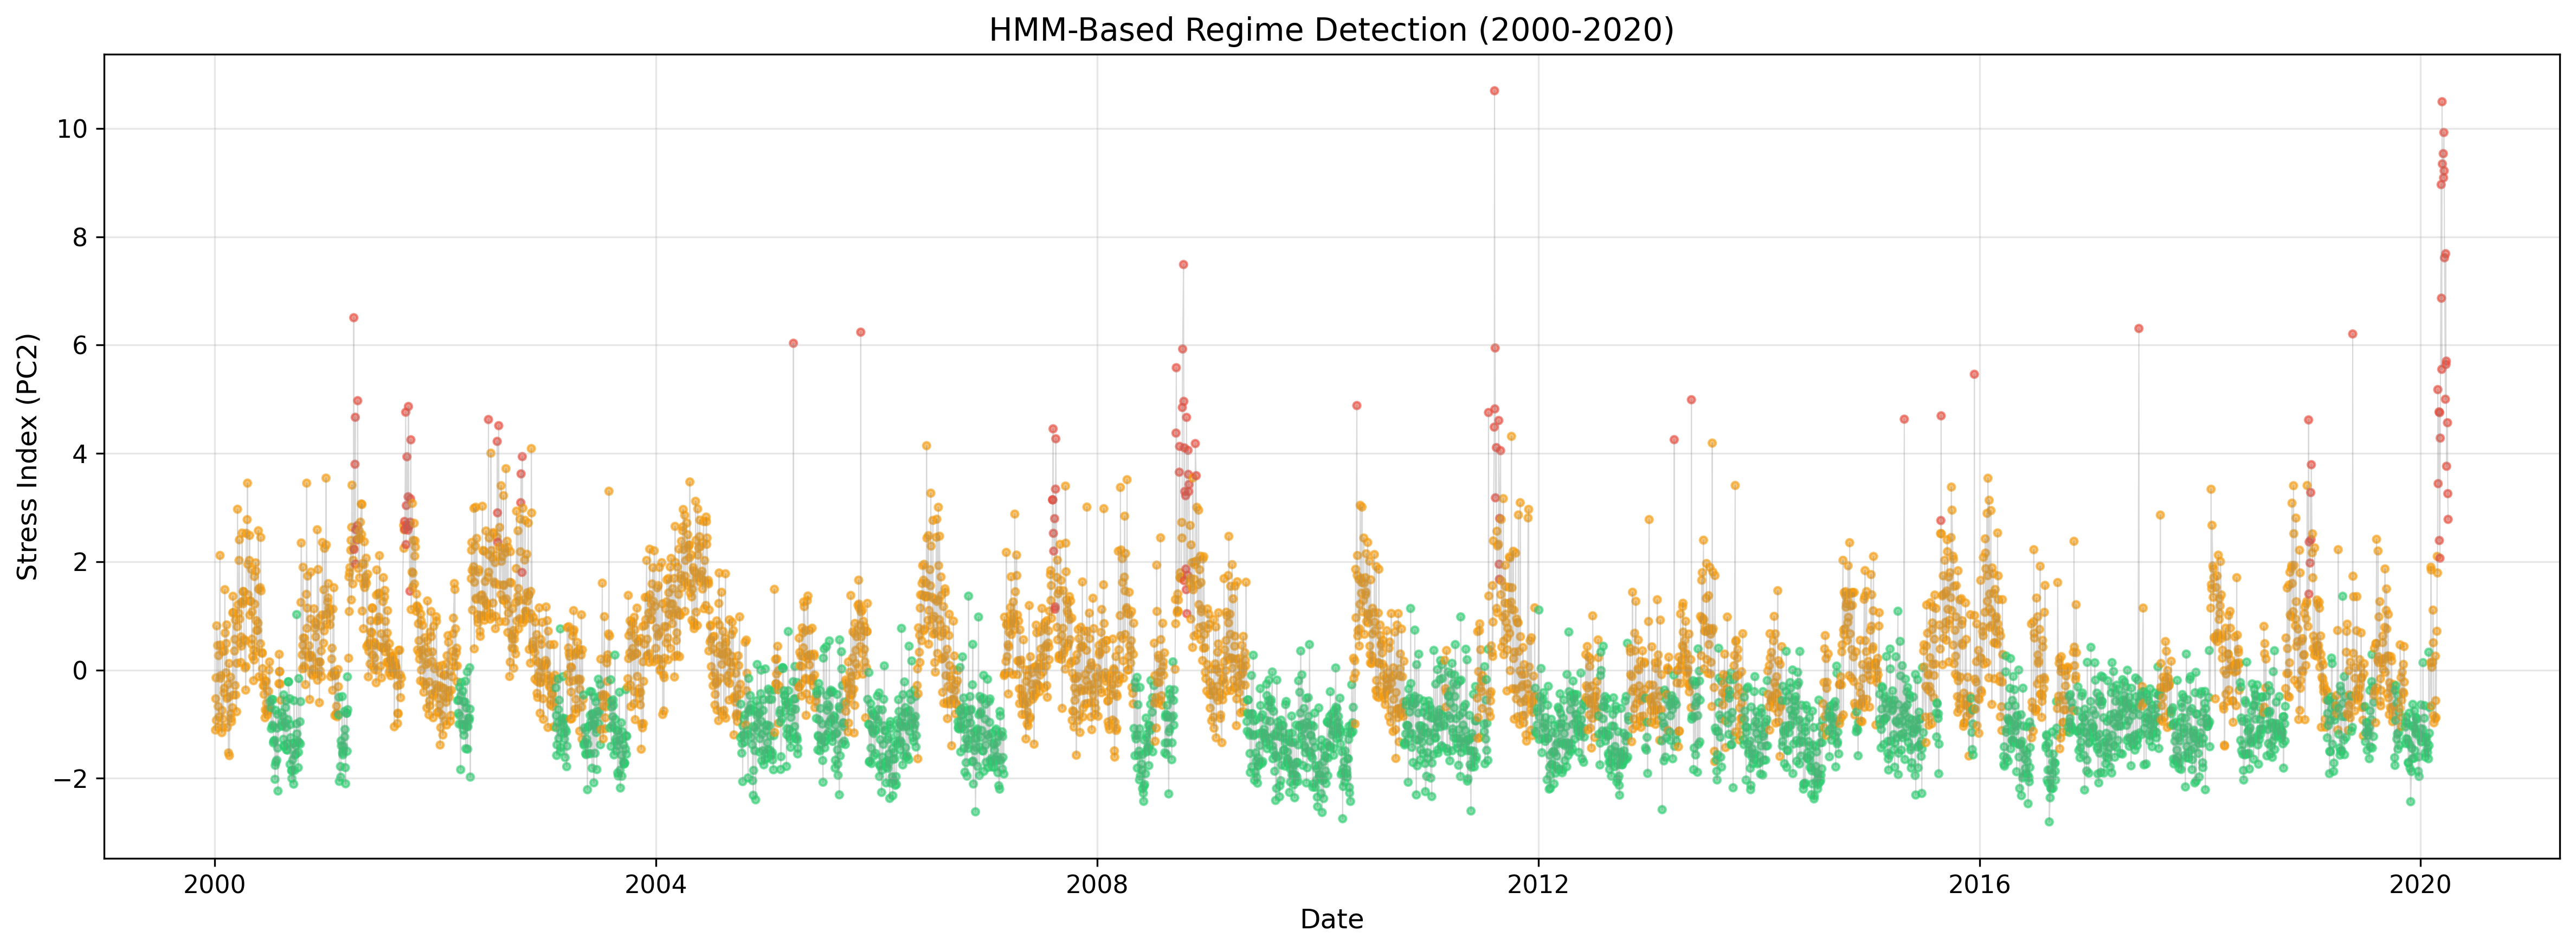

In [44]:
# Plot regime timeline for full period
plot_regime_timeline(
    dates=hmm_df['date'],
    regimes=hmm_df['regime'].values,
    volatility=hmm_df['stress_pc2'].values,
    thresholds=None,  # No quantile thresholds for HMM (state-based)
    title='HMM-Based Regime Detection (2000-2020)',
    ylabel='Stress Index (PC2)',
    save_path='../results/figures/hmm_regime_timeline.png',
    figsize=(16, 6)
)

### 3.3. Regime Distribution

Display regime distribution with percentage breakdown.

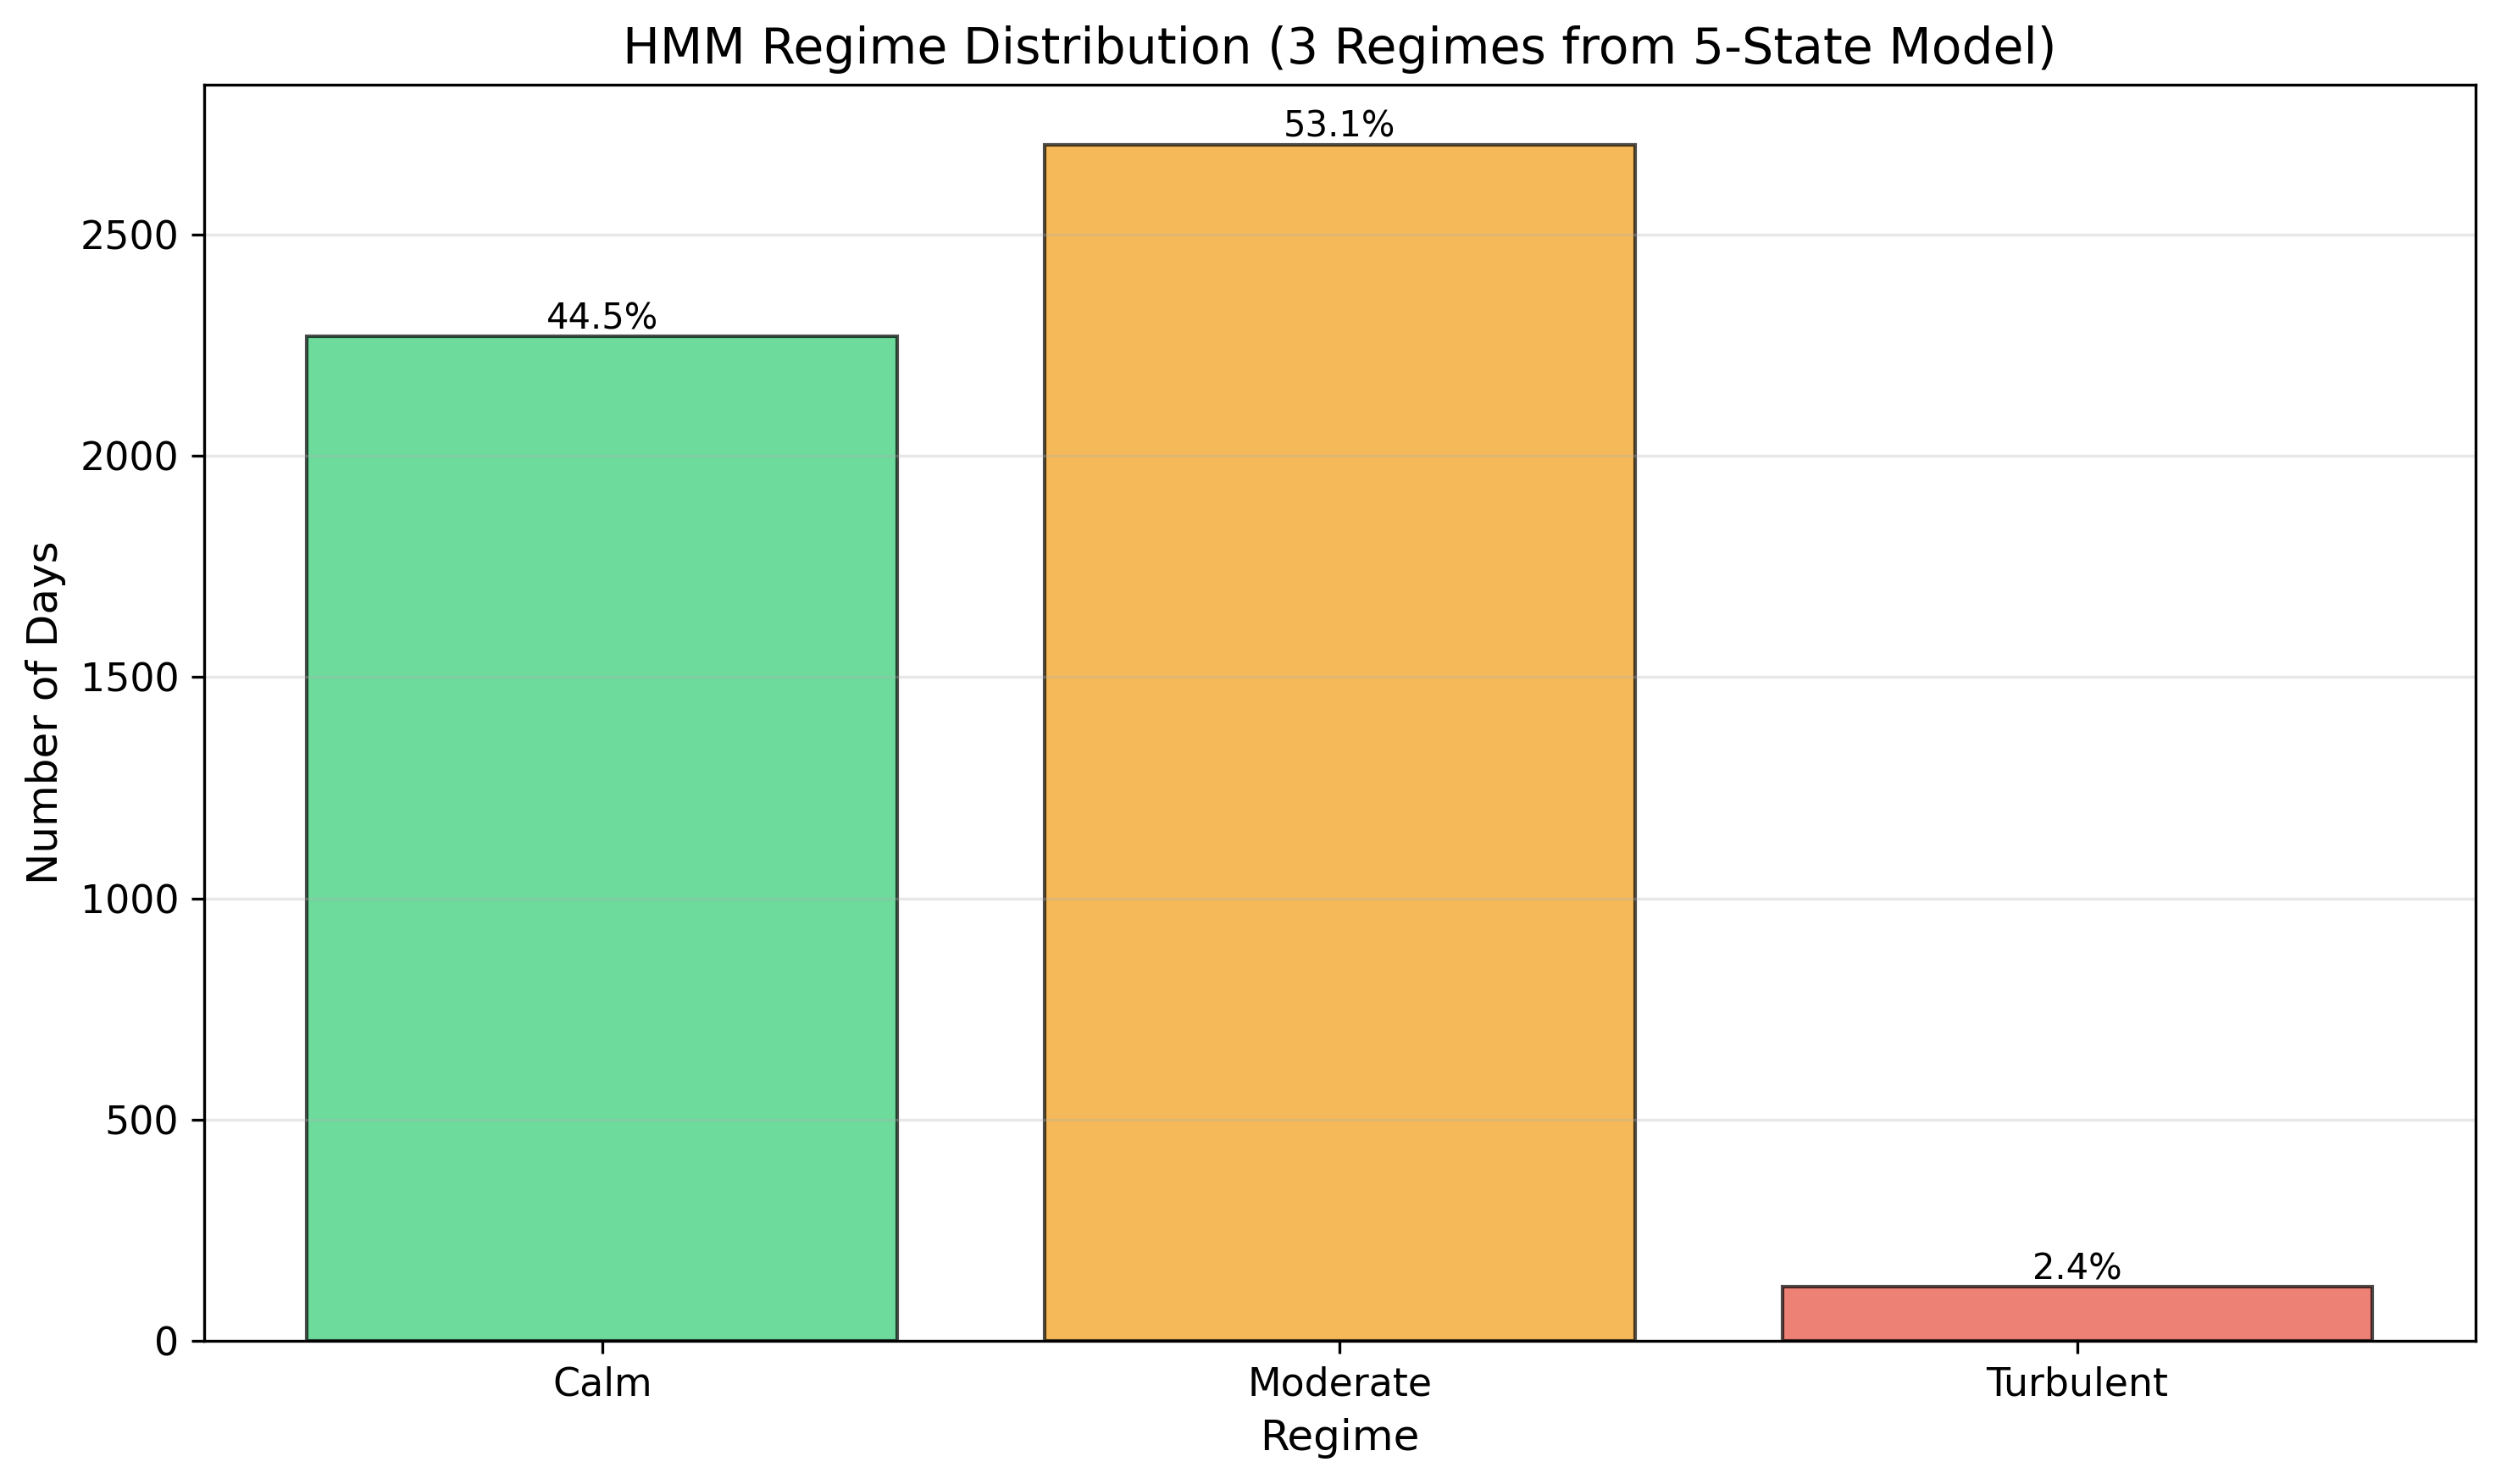


Regime Distribution:
  Calm: 2269 days (44.5%)
  Moderate: 2703 days (53.1%)
  Turbulent: 122 days (2.4%)


In [45]:
# Define colors for consistency
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}

# Compute regime distribution
regime_counts = pd.Series(hmm_states_labeled).value_counts().sort_index()
regime_pcts = (regime_counts / len(hmm_states_labeled) * 100)

# Plot regime distribution bar chart
plot_regime_distribution_bar(
    regimes=hmm_states_labeled,
    regime_labels=label_names,
    colors=colors,
    title='HMM Regime Distribution (3 Regimes from 5-State Model)',
    save_path='../results/figures/hmm_regime_distribution.png',
    figsize=(10, 6)
)

# Print summary
print("\nRegime Distribution:")
for regime in regime_counts.index:
    print(f"  {label_names[regime]}: {regime_counts[regime]} days ({regime_pcts[regime]:.1f}%)")

## 4. 2008 Financial Crisis Deep Dive

Validate HMM stress regimes against the 2008 financial crisis with detailed event markers.


### 4.1. Regime Transition Analysis

Analyze HMM regime transitions during the 2008 crisis. Calculate transition probabilities and persistence metrics to understand regime dynamics during extreme market stress.


Regime Persistence During 2008 Crisis

Calm:
  Expected duration: 89.33 days

Moderate:
  Expected duration: 56.75 days

Turbulent:
  Expected duration: 6.60 days


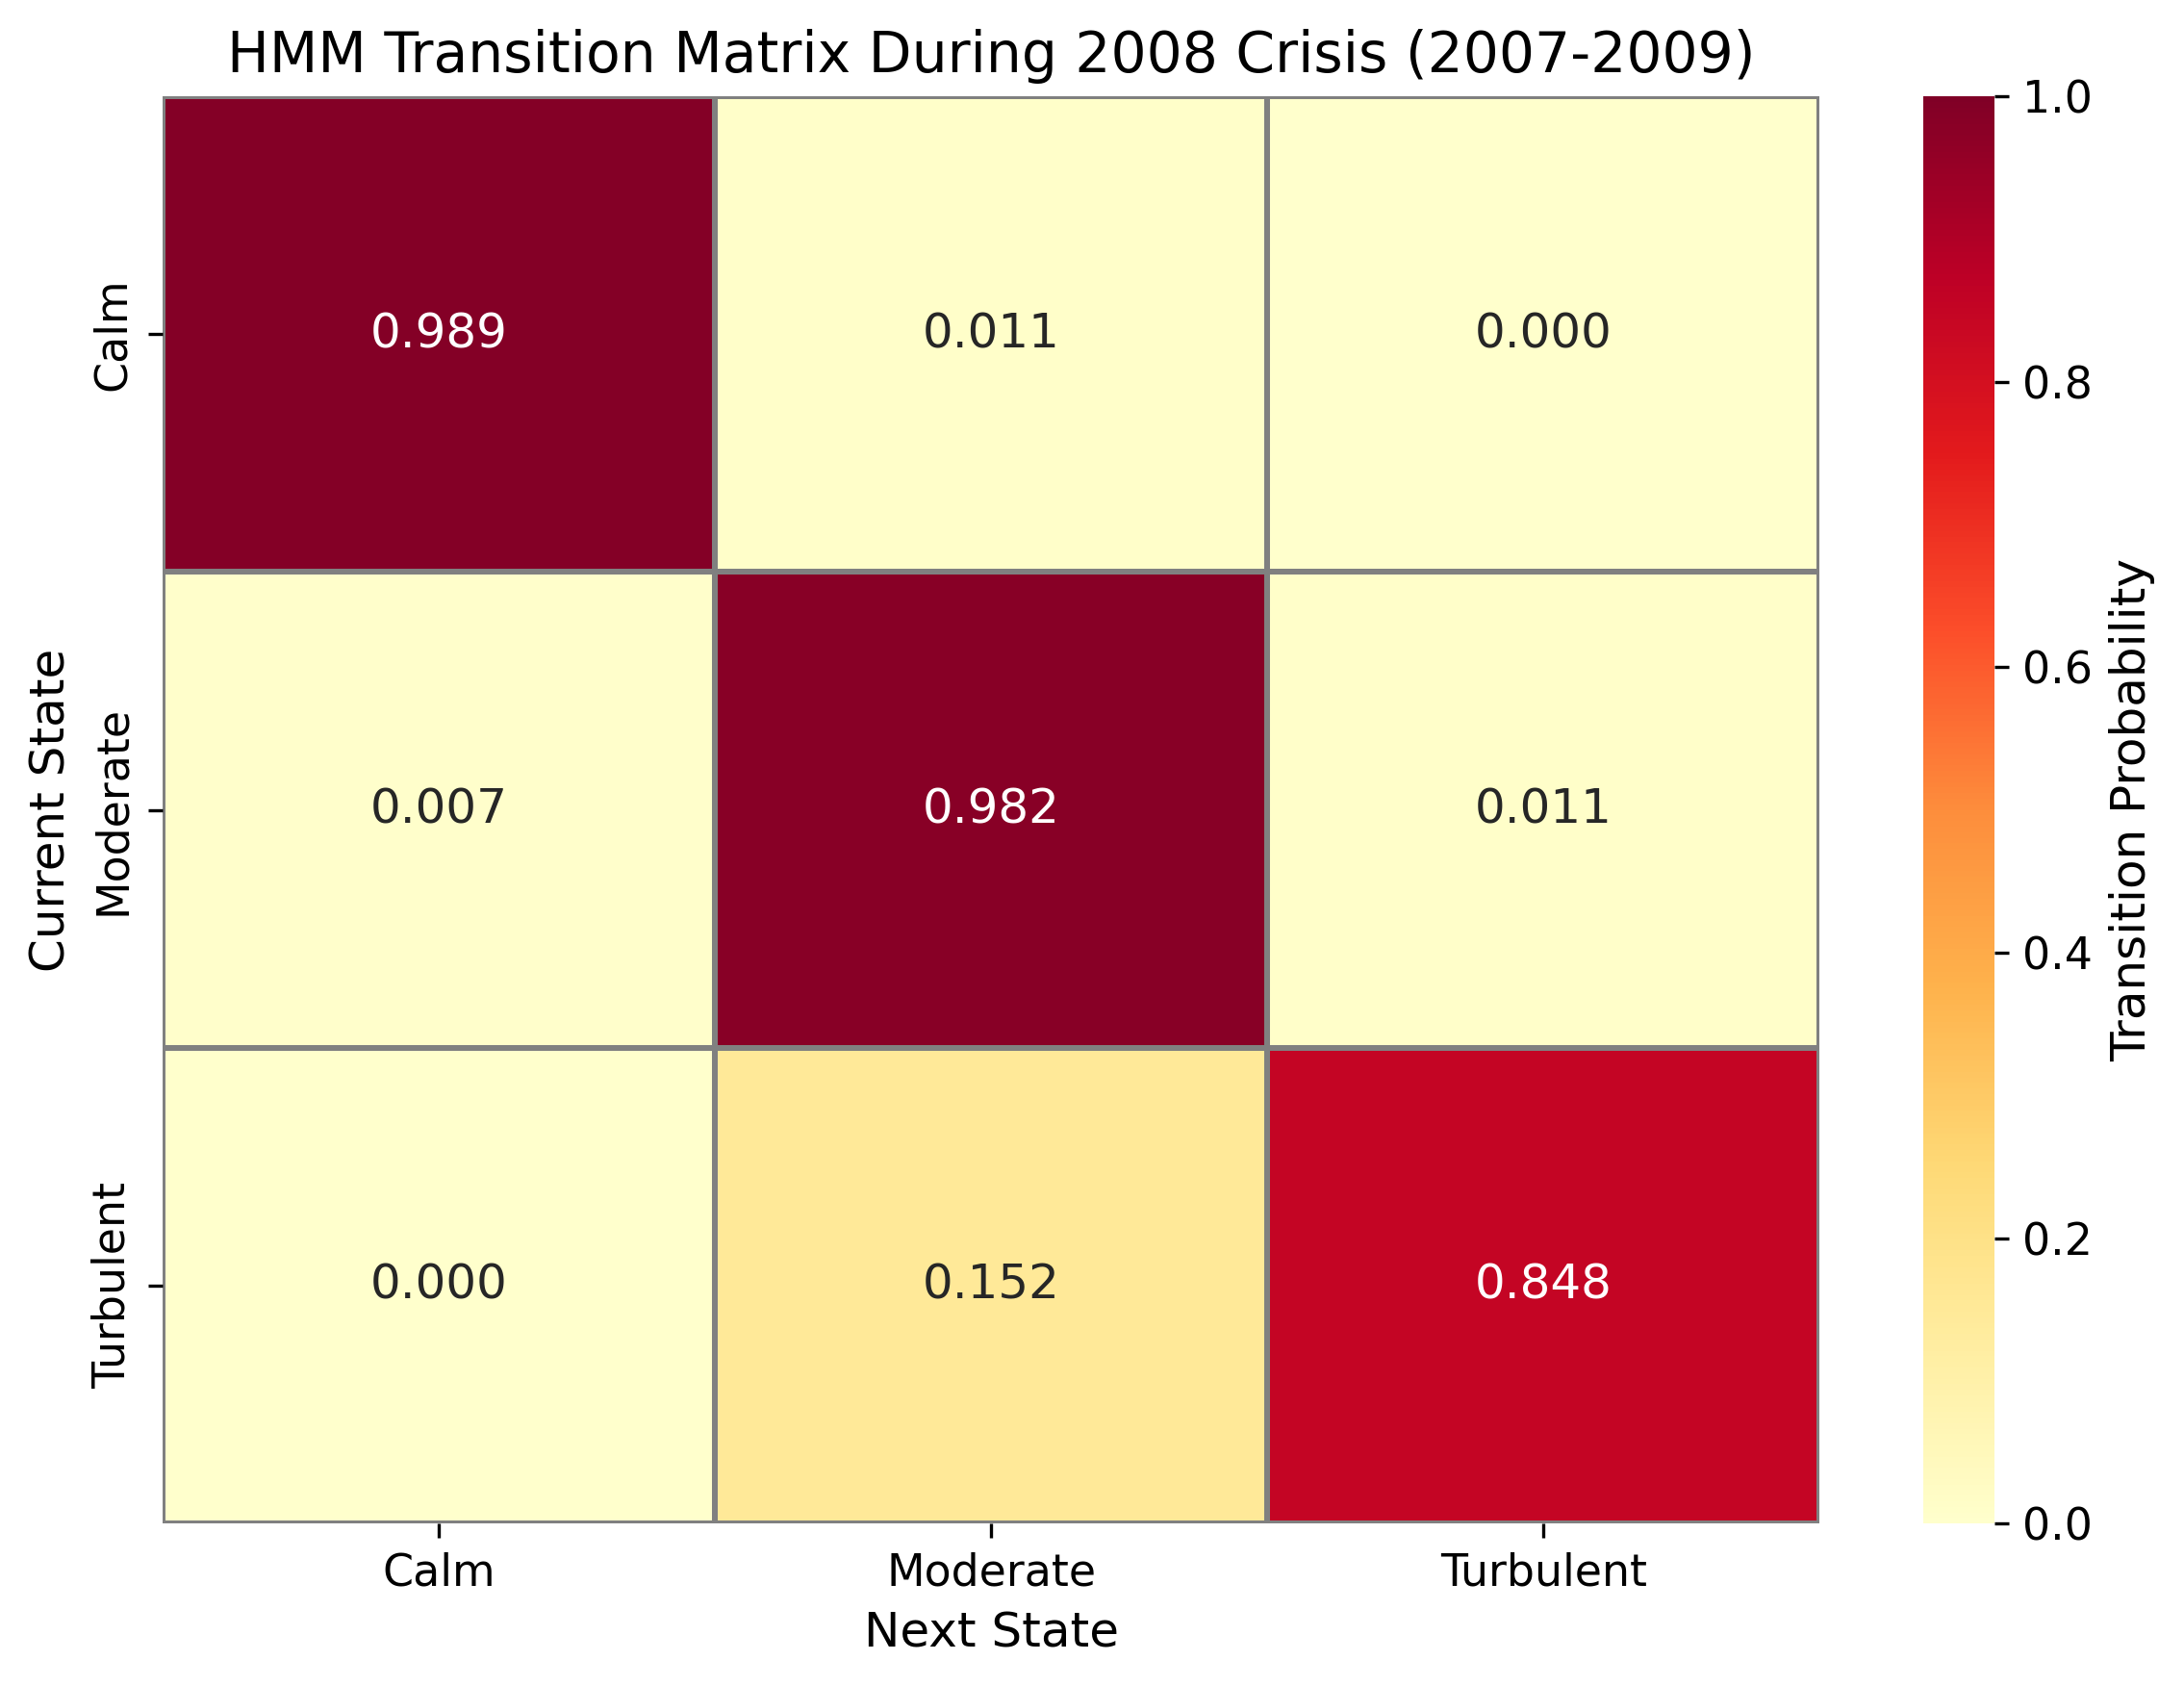

In [54]:
# Filter data for 2008 crisis period
crisis_start = '2007-01-01'
crisis_end = '2009-12-31'

crisis_mask = (hmm_df['date'] >= crisis_start) & (hmm_df['date'] <= crisis_end)
crisis_regimes = hmm_df.loc[crisis_mask, 'regime'].values


# Compute transition matrix and metrics
trans_matrix_crisis = compute_transition_matrix(crisis_regimes)
metrics_crisis = compute_persistence_metrics(trans_matrix_crisis)

# Display results
trans_matrix_crisis_df = pd.DataFrame(
    trans_matrix_crisis,
    index=[label_names[i] for i in range(3)],
    columns=[label_names[i] for i in range(3)]
)

print("\n" + "="*60)
print("Regime Persistence During 2008 Crisis")
print("="*60)
for i in range(3):
    print(f"\n{label_names[i]}:")
    if metrics_crisis['avg_duration'][i] != np.inf:
        print(f"  Expected duration: {metrics_crisis['avg_duration'][i]:.2f} days")
    else:
        print(f"  Expected duration: infinite (never exits)")

# Plot transition matrix heatmap
plot_transition_matrix_heatmap(
    transition_matrix=trans_matrix_crisis,
    regime_labels=label_names,
    title='HMM Transition Matrix During 2008 Crisis (2007-2009)',
    save_path='../results/figures/hmm_transition_matrix_2008.png',
    figsize=(8, 6)
)

### 4.2. Crisis Period Visualization

Visualize HMM regime evolution during the 2008 crisis with key event markers.

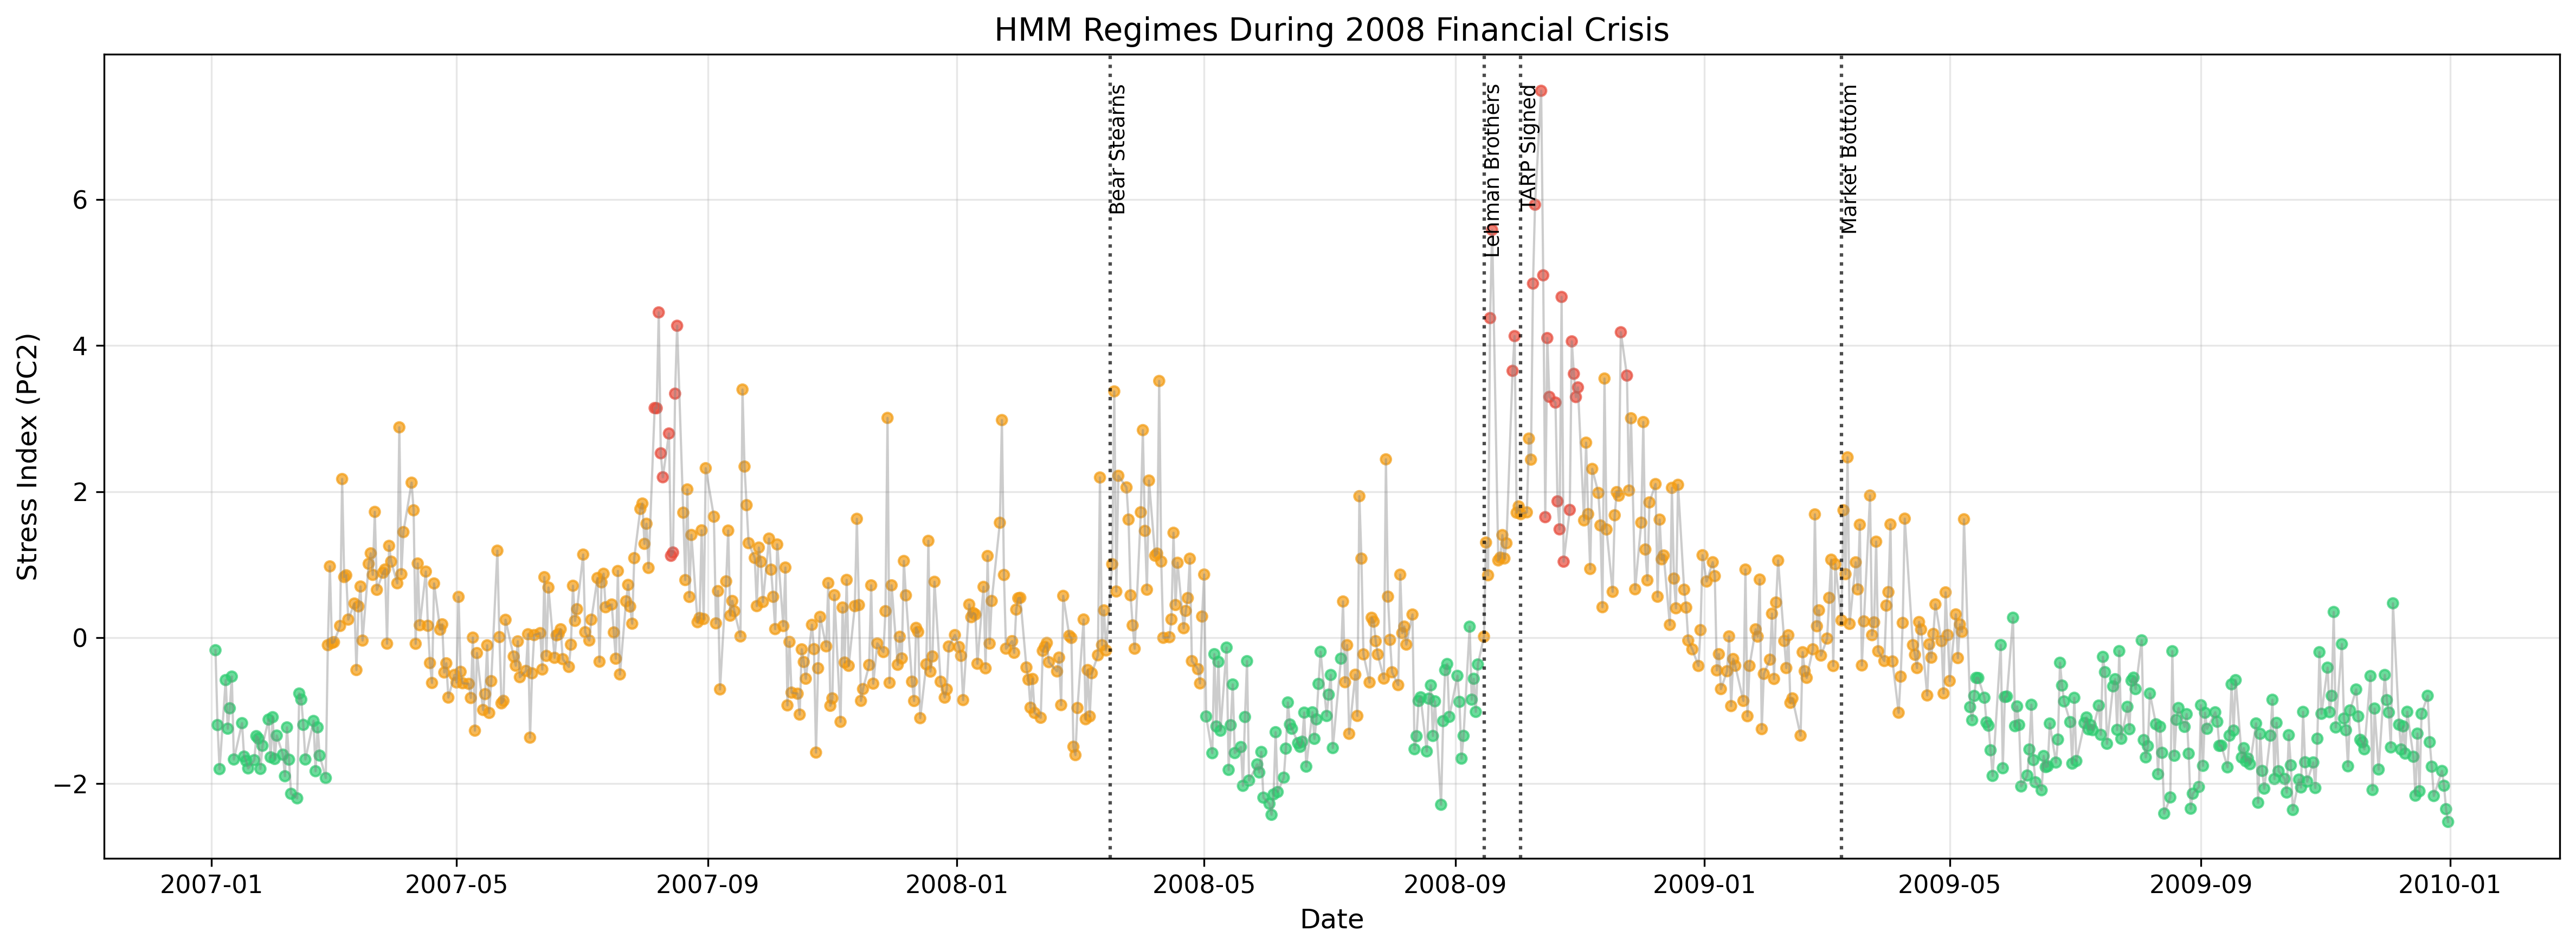


Regime distribution during 2008 crisis:
  Calm: 269 days (35.6%)
  Moderate: 454 days (60.1%)
  Turbulent: 33 days (4.4%)


In [47]:
# Define key events during 2008 crisis
events = {
    '2008-03-16': 'Bear Stearns',
    '2008-09-15': 'Lehman Brothers',
    '2008-10-03': 'TARP Signed',
    '2009-03-09': 'Market Bottom'
}

# Plot crisis period with HMM regimes
plot_crisis_period(
    dates=hmm_df['date'],
    regimes=hmm_df['regime'].values,
    volatility=hmm_df['stress_pc2'].values,
    thresholds=None,  # No quantile thresholds for HMM
    crisis_start='2007-01-01',
    crisis_end='2009-12-31',
    events=events,
    title='HMM Regimes During 2008 Financial Crisis',
    ylabel='Stress Index (PC2)',
    save_path='../results/figures/crisis_2008_validation.png',
    figsize=(16, 6)
)

# Print regime distribution during crisis
crisis_mask = (hmm_df['date'] >= '2007-01-01') & (hmm_df['date'] <= '2009-12-31')
crisis_df = hmm_df[crisis_mask]
print(f"\nRegime distribution during 2008 crisis:")
for regime in range(3):
    count = (crisis_df['regime'] == regime).sum()
    pct = count / len(crisis_df) * 100
    print(f"  {label_names[regime]}: {count} days ({pct:.1f}%)")

## 5. Full Period Regime Analysis

Comprehensive statistics, transition dynamics, validation against additional crises, and PC2 vs drawdown comparison.


### 5.1. Regime Statistics


In [55]:
print("\n" + "="*60)
print("Regime Characteristics:")
print("="*60)
for regime in range(3):
    regime_data = state_stats[state_stats['state'] == regime].iloc[0]
    print(f"\n{label_names[regime]} Regime:")
    print(f"  Count: {int(regime_data['count'])} days ({regime_data['percentage']:.1f}%)")
    print(f"  Mean Systemic Stress: {regime_data['mean']:.3f}")
    print(f"  Std Systemic Stress:  {regime_data['std']:.3f}")
    print(f"  Range: [{regime_data['min']:.3f}, {regime_data['max']:.3f}]")



Regime Characteristics:

Calm Regime:
  Count: 2269 days (44.5%)
  Mean Systemic Stress: -1.101
  Std Systemic Stress:  0.583
  Range: [-2.805, 1.365]

Moderate Regime:
  Count: 2703 days (53.1%)
  Mean Systemic Stress: 0.453
  Std Systemic Stress:  1.013
  Range: [-1.691, 4.315]

Turbulent Regime:
  Count: 122 days (2.4%)
  Mean Systemic Stress: 4.166
  Std Systemic Stress:  2.048
  Range: [1.041, 10.698]


### 5.2. Transition Matrix and Persistence

Compute empirical transition probabilities and persistence metrics for the 3 final regimes.

In [ ]:
# Compute full period transition matrix
trans_matrix = compute_transition_matrix(hmm_states_labeled)
persistence_metrics = compute_persistence_metrics(trans_matrix)

# Create DataFrame for display
trans_matrix_df = pd.DataFrame(
    trans_matrix,
    index=[label_names[i] for i in range(3)],
    columns=[label_names[i] for i in range(3)]
)


HMM Regime Statistics (3 Regimes):
 state      mean      std       min       max  count  percentage
     0 -1.101183 0.582718 -2.805361  1.364933   2269   44.542599
     1  0.452964 1.013396 -1.690556  4.315479   2703   53.062426
     2  4.165591 2.047935  1.040721 10.697672    122    2.394974


### 5.3. Regime Visualizations

Visualize the transition matrix as a heatmap.

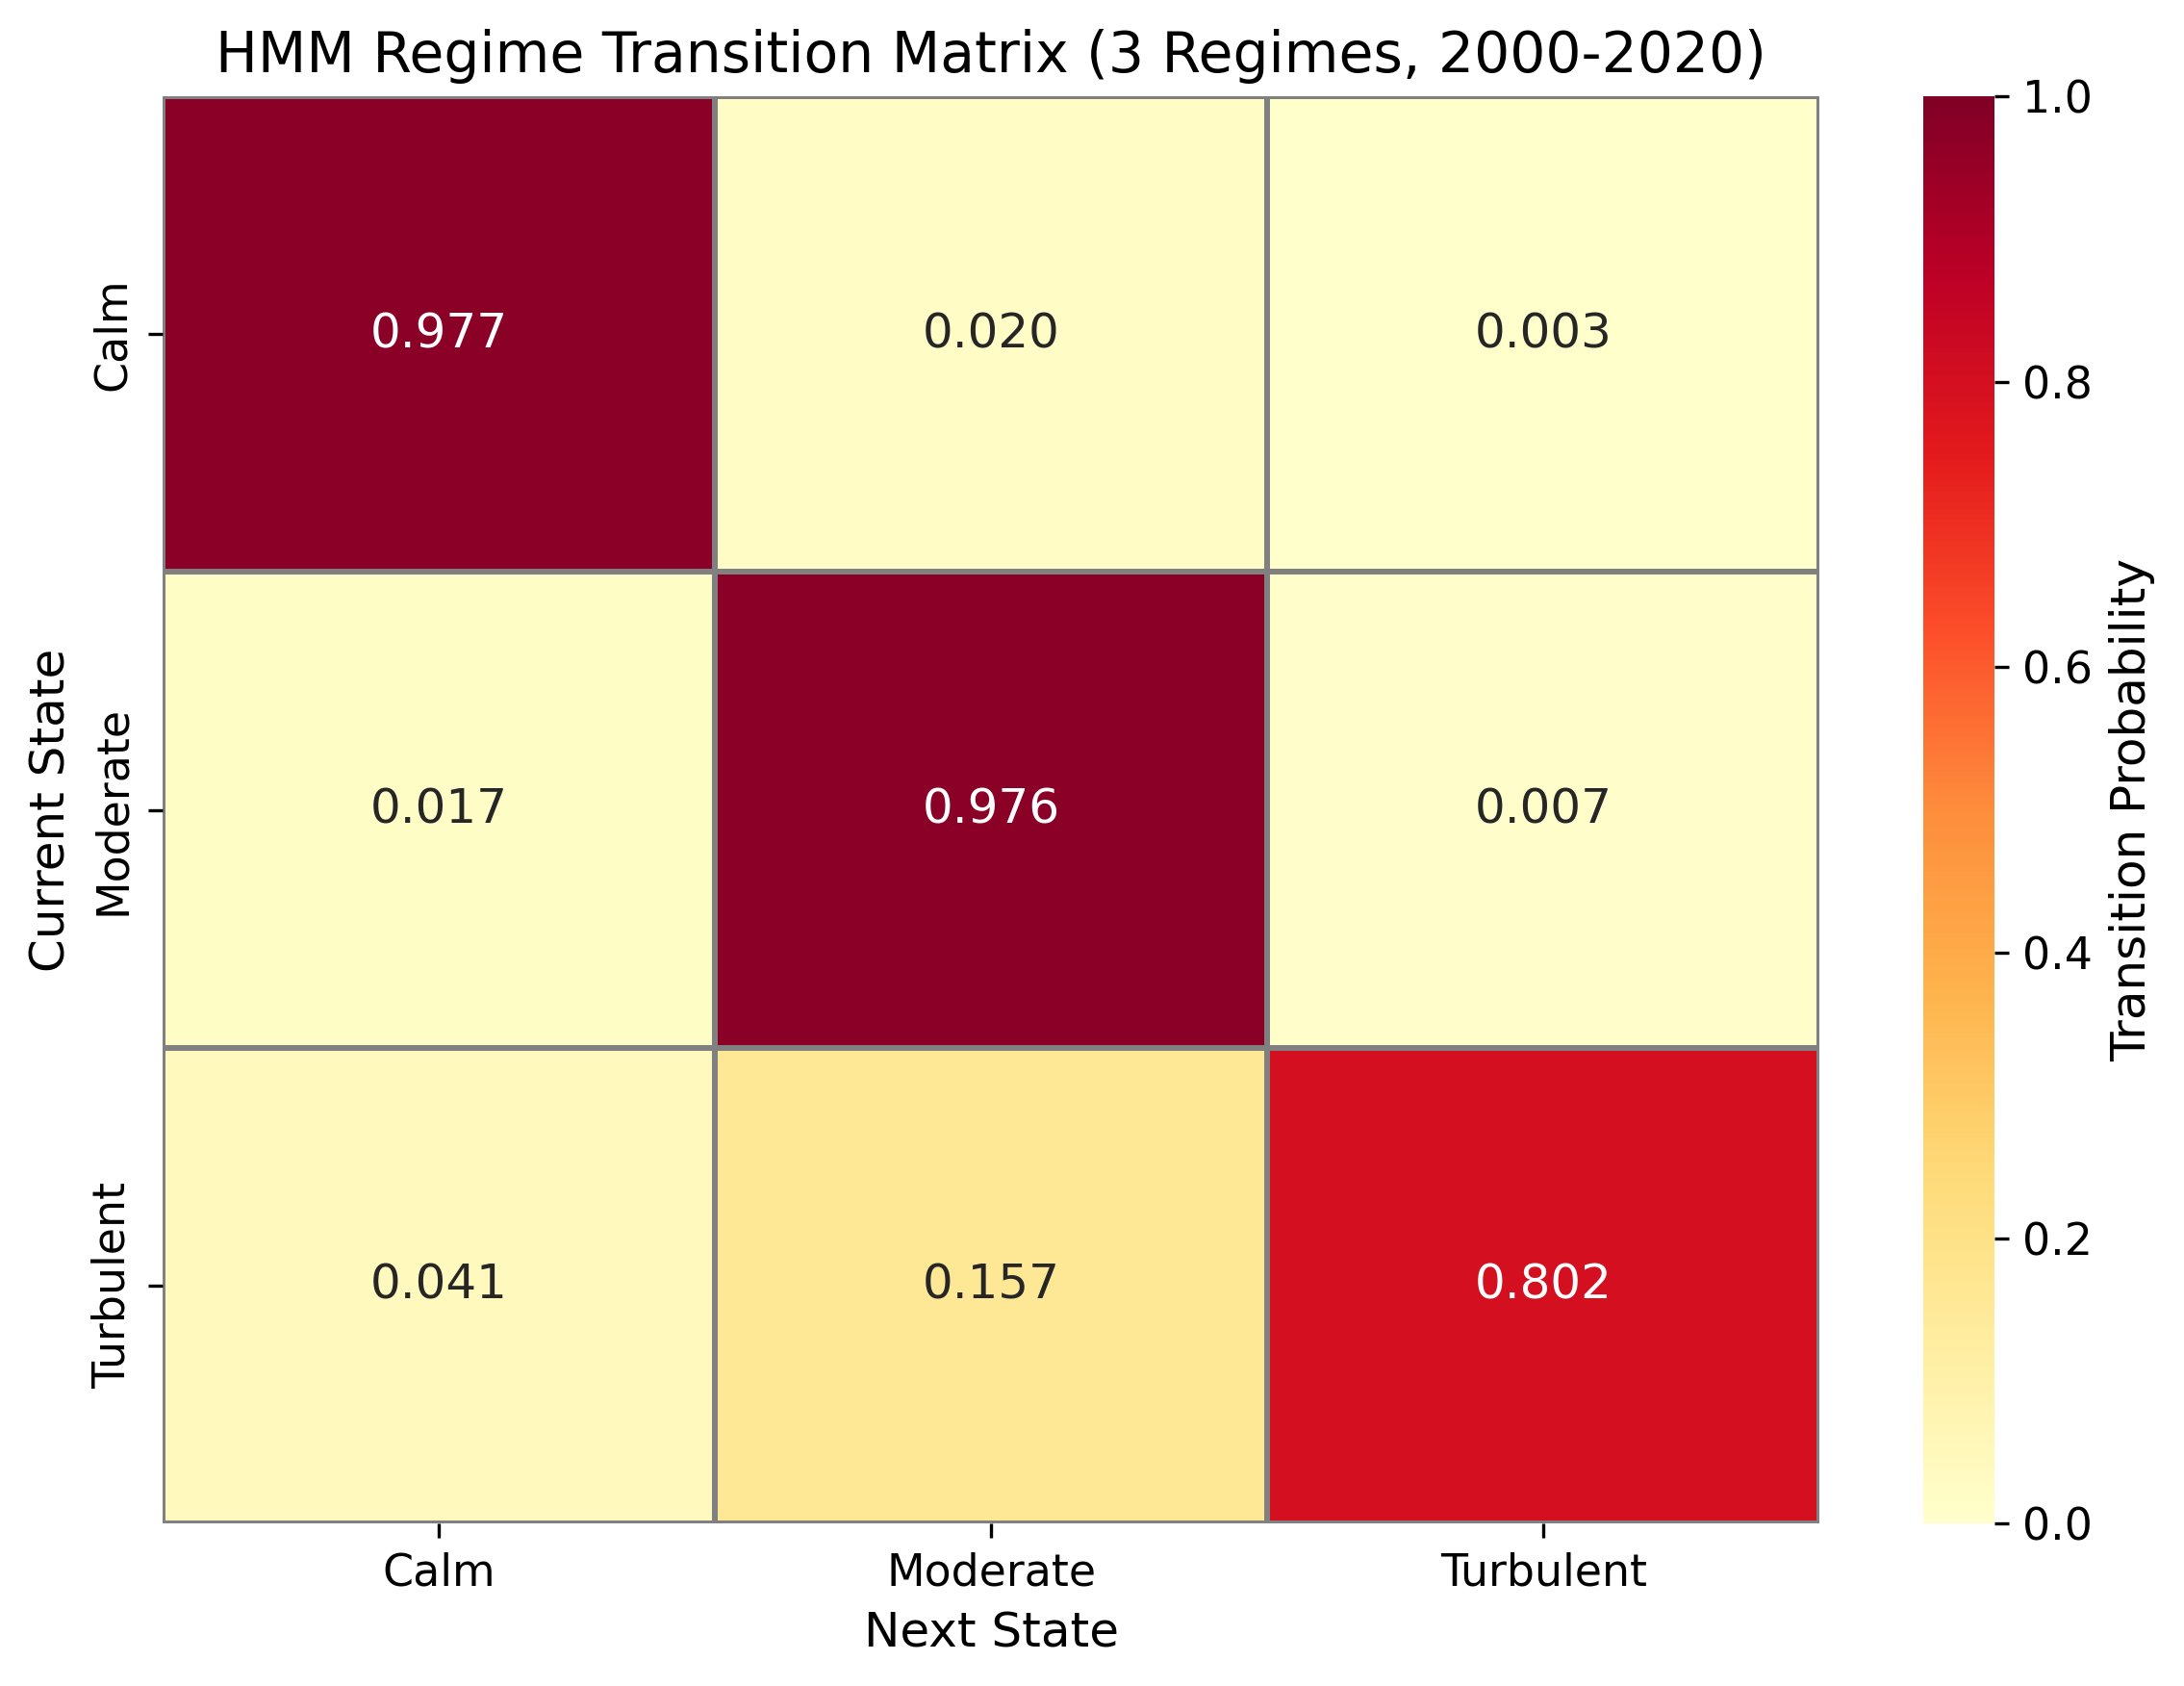

In [50]:
# Plot transition matrix heatmap
plot_transition_matrix_heatmap(
    transition_matrix=trans_matrix,
    regime_labels=label_names,
    title='HMM Regime Transition Matrix (3 Regimes, 2000-2020)',
    save_path='../results/figures/hmm_transition_matrix.png',
    figsize=(8, 6)
)

### 5.4. Dotcom Bubble Period

Validate HMM regimes during the 2000-2002 dotcom bubble burst.


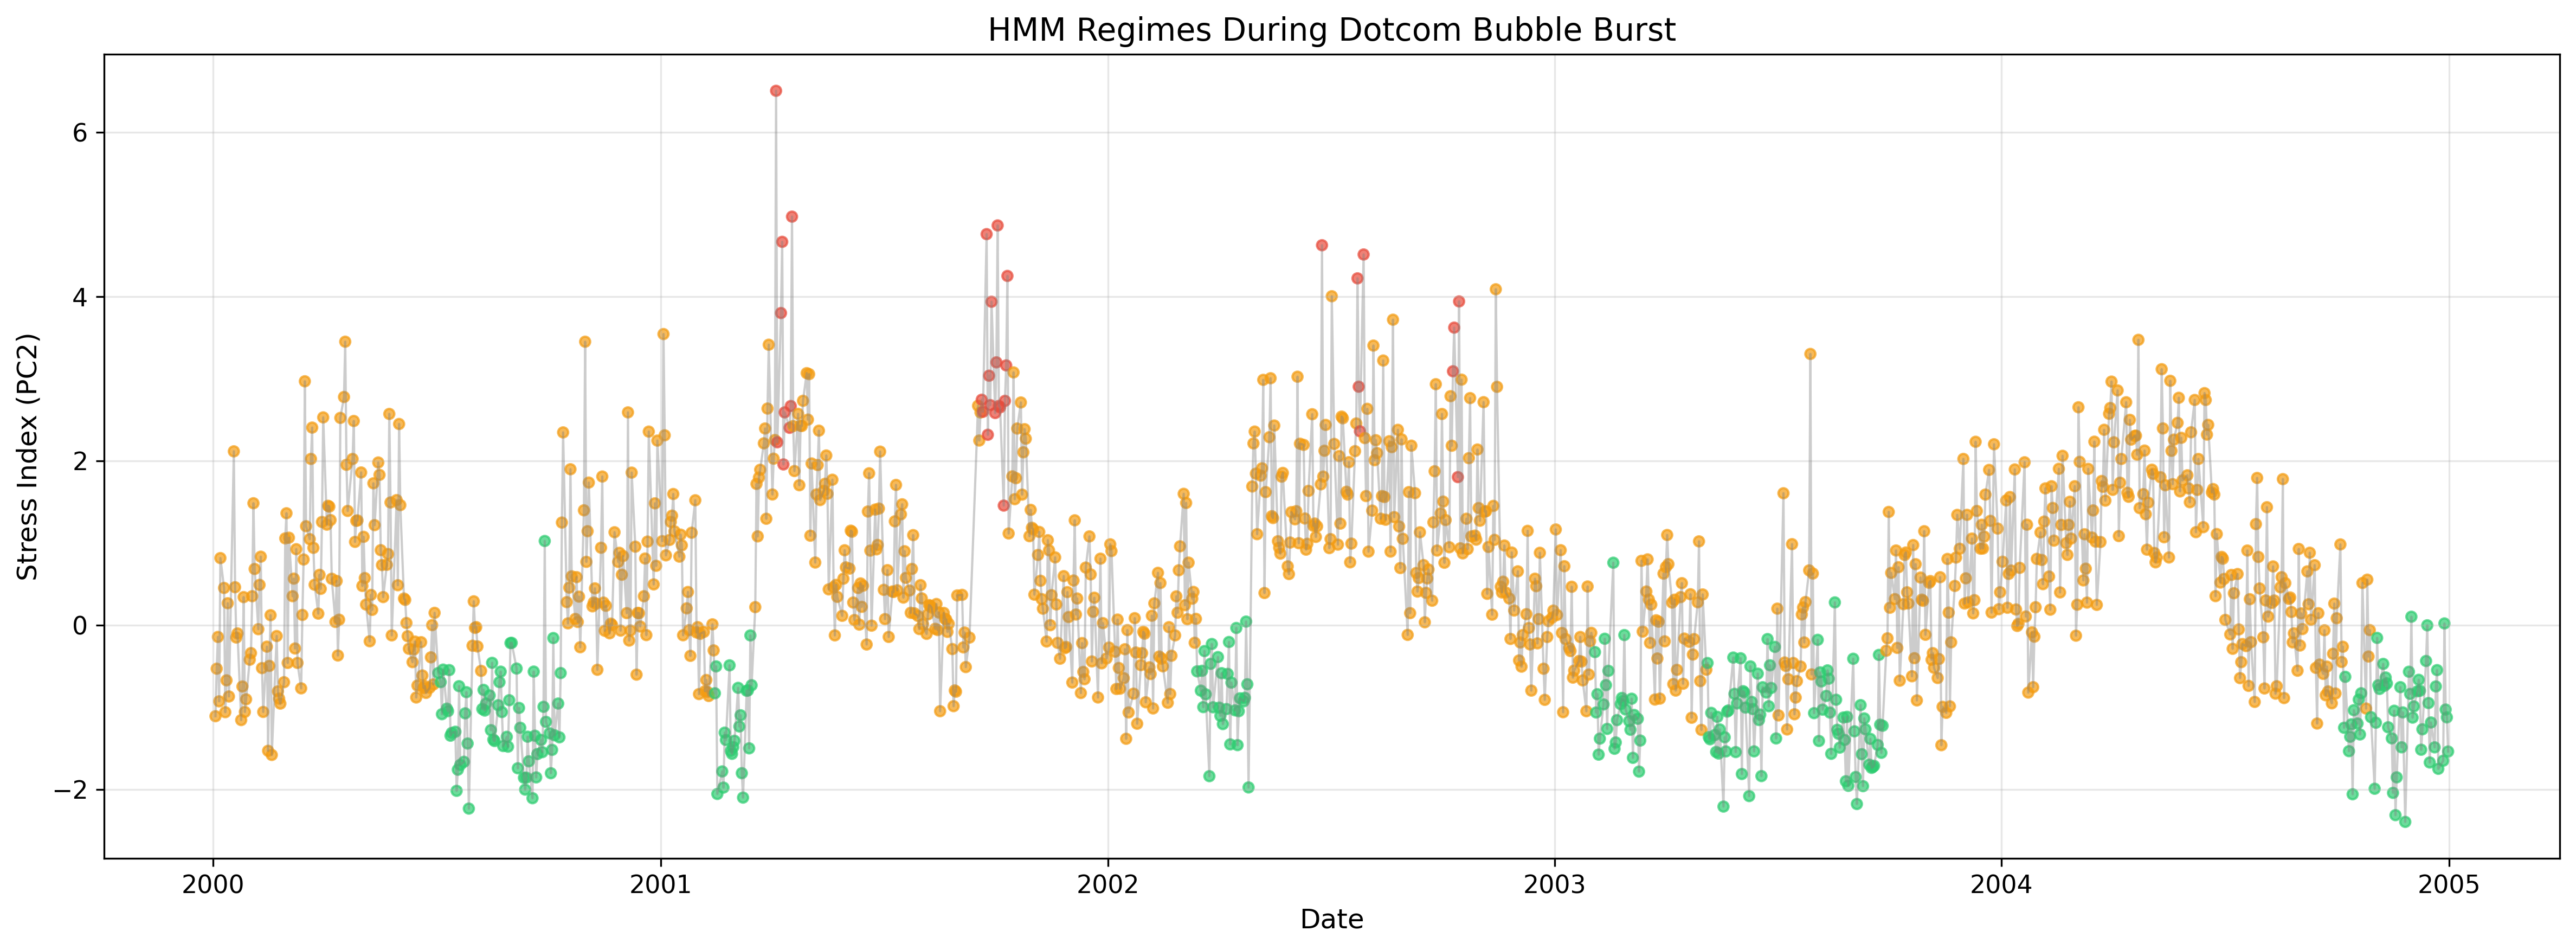

In [51]:
# Plot dotcom bubble period with HMM regimes
plot_crisis_period(
    dates=hmm_df['date'],
    regimes=hmm_df['regime'].values,
    volatility=hmm_df['stress_pc2'].values,
    thresholds=None,
    crisis_start='2000-01-01',
    crisis_end='2004-12-31',
    events=None,  # No specific event markers for dotcom
    title='HMM Regimes During Dotcom Bubble Burst',
    ylabel='Stress Index (PC2)',
    save_path='../results/figures/hmm_crisis_dotcom.png',
    figsize=(16, 6)
)